# 04 - Extended LCOE: Hybrid Heating + Cooling
**SPE Africa Geothermal Datathon 2026 - Challenge 2 - Team Vent Squad**

The stock TNO `LCOE.xlsx` workbook prices **heat only**. Challenge 2 asks for the
*hybrid* heating + cooling design, so I re-built the TNO financed-LCOE model in
`src/lcoe.py` and extended it with a cooling block. Re-building in code lets me
drive sensitivities (the tornado) and the bonus pipeline programmatically.

The risk in re-building is silent drift from the published model, so the engine
is **gated**: it must reproduce the stock workbook's heat case to 5.769 EUR/GJ
before any of my numbers are trusted. That check is the first thing this
notebook runs.

**What this establishes**
1. The TNO heat LCOE is reproduced exactly (validation gate).
2. Heat LCOE for *my* 2-doublet, 77 C, 4-well Rotliegend scheme.
3. Cooling LCOE (Design A: ATES + trim heat pump).
4. Design A vs Design B (absorption chiller) - the recommendation, audited.
5. Tornado on the top blended-LCOE drivers.
6. Refreshes `data/processed/LCOE_hybrid.xlsx`.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "src").exists():
    sys.path.insert(0, str(ROOT.parent))

import pandas as pd
import matplotlib.pyplot as plt

from src.lcoe import (HeatCase, CoolingCase, heat_economics, cooling_economics,
                      validate_reference, REFERENCE_LCOE_EUR_GJ)
from src.surface import SchemeConfig, size_design_a, size_design_b, comparison_table
from src.tornado import tornado_data, plot_tornado
from src.build_lcoe_workbook import build as build_workbook
from src.paths import FIGURES
pd.set_option("display.width", 160, "display.max_columns", 20)

## 1. Validation gate - reproduce the TNO heat reference

If the engine cannot reproduce the published 5.769 EUR/GJ for the stock inputs,
nothing downstream is trustworthy. This asserts the match.

In [2]:
ours = validate_reference()
print(f"our engine     : {ours:.6f} EUR/GJ")
print(f"TNO published  : {REFERENCE_LCOE_EUR_GJ:.6f} EUR/GJ")
print(f"match          : {'PASS' if abs(ours-REFERENCE_LCOE_EUR_GJ)<1e-3 else 'FAIL'}")

our engine     : 5.769049 EUR/GJ
TNO published  : 5.769049 EUR/GJ
match          : PASS


## 2. Heat LCOE for the chosen scheme

My reservoir is cooler (77 C vs the TNO reference's 93.7 C) and less productive
per well, so a single doublet only makes ~5 MWth (P50). To clear the 10 MWth
heating demand I need a **2-doublet (4-well) scheme**, with heat sales
capped at the 10 MWth delivered demand (the 2-doublet resource P50 is 14.1
MWth, so the surplus de-risks delivery rather than inflating the economics). More wells for less heat than the TNO
reference means a higher unit cost - that is the honest finding, not a defect.

In [3]:
cfg = SchemeConfig()
heat = heat_economics(cfg.heat_case(), heat_mwth=cfg.heat_delivered_mwth)
print(f"heat delivered (demand): {heat['heat_mwth']:.2f} MWth")
print(f"implied scheme flow    : {heat['flow_ls']:.1f} L/s")
print(f"drilling cost / well   : {heat['drill_mln_per_well']:.2f} mln EUR  ({cfg.n_wells} wells)")
print(f"subsurface capex       : {heat['subsurface_capex_mln']:.2f} mln EUR")
print(f"heat plant capex       : {heat['heat_capex_mln']:.2f} mln EUR")
print(f"annual opex            : {heat['annual_opex_eur']/1e6:.2f} mln EUR/yr")
print(f"LCOE heat              : {heat['lcoe_eur_gj']:.2f} EUR/GJ "
      f"({heat['lcoe_eur_gj']*3.6:.1f} EUR/MWhth)")
print(f"(TNO heat-only ref     : {REFERENCE_LCOE_EUR_GJ:.2f} EUR/GJ)")

heat delivered (demand): 10.00 MWth
implied scheme flow    : 52.0 L/s
drilling cost / well   : 3.67 mln EUR  (4 wells)
subsurface capex       : 15.00 mln EUR
heat plant capex       : 1.50 mln EUR
annual opex            : 0.50 mln EUR/yr
LCOE heat              : 11.76 EUR/GJ (42.4 EUR/MWhth)
(TNO heat-only ref     : 5.77 EUR/GJ)


## 3. Cooling LCOE - Design A (ATES + trim heat pump)

Cooling is delivered mostly by cold water banked in the ATES cold well over
winter; an electric heat pump in chiller mode trims the summer peak. The blended
system COP is ~10 (ATES circulation plus a heat-pump trim, ~70/30), the economic
case for ATES over an absorption chiller that would burn the geothermal heat I am
trying to sell. The 6 ATES pairs are sized so cooling clears 5 MWth at the low end.

In [4]:
cool = cooling_economics(CoolingCase(cooling_mwth=cfg.demand_cooling_mwth, ates_pairs=6))
print(f"cooling delivered      : {cool['cooling_mwth']:.2f} MWth")
print(f"ATES pairs             : {cool['ates_pairs']}  -> supply {cool['ates_supply_mwth']:.1f} MWth")
print(f"cooling capex          : {cool['capex_mln']:.2f} mln EUR "
      f"(ATES {cool['ates_capex_mln']:.2f} + chiller {cool['chiller_capex_mln']:.2f})")
print(f"cooling electricity    : {cool['elec_mwh']:.0f} MWh/yr")
print(f"LCOE cooling           : {cool['lcoe_eur_gj']:.2f} EUR/GJ")

cooling delivered      : 5.00 MWth
ATES pairs             : 6  -> supply 6.0 MWth
cooling capex          : 4.80 mln EUR (ATES 4.20 + chiller 0.60)
cooling electricity    : 1000 MWh/yr
LCOE cooling           : 22.98 EUR/GJ


## 4. Design A vs Design B - the recommendation, audited

**Design A** makes cold from ATES + a trim heat pump. **Design B** makes cold
from a LiBr/H2O absorption chiller driven by geothermal heat. The comparison
charges Design B's driving heat at the heat LCOE as an internal transfer price,
so the trade-off is fair.

Two things decide it, and cost is not one of them:
1. **It keeps the heat we sell** - Design B ties up ~7 MWth of geothermal heat
   to make 5 MWth of cold; Design A keeps that heat for the district.
2. **Physics** - a single-effect LiBr/H2O chiller wants 85-95 C drive heat; my
   reservoir is **77 C**, marginal-to-insufficient. On cost the two are a wash
   once ATES is sized robustly (6 pairs), so the case for A rests on heat and physics.

In [5]:
comp = comparison_table(cfg, ates_pairs=6)
comp

,design,heat_mwth,cooling_mwth,geo_heat_consumed_for_cooling_mwth,ates_pairs,lcoe_heat_eur_gj,lcoe_cool_eur_gj,capex_total_mln,cooling_elec_mwh_yr,meets_heating,meets_cooling
0,A (ATES + heat pump),10.0,5.0,0.00,6,11.76,22.98,21.30,1000.0,True,True
1,B (absorption chiller),10.0,5.0,7.14,0,11.76,23.37,17.75,400.0,True,True


In [6]:
a, b = size_design_a(cfg), size_design_b(cfg)
print(f"Design A cooling LCOE  : {a['lcoe_cool_eur_gj']:.2f} EUR/GJ")
print(f"Design B cooling LCOE  : {b['lcoe_cool_eur_gj']:.2f} EUR/GJ")
print(f"Design B diverts       : {b['geo_heat_consumed_for_cooling_mwth']:.1f} MWth of geothermal heat")
print("Recommendation: Design A (comparable cooling cost, keeps heat for sale, "
      "and 77 C is too cool for a single-effect absorption chiller).")

Design A cooling LCOE  : 22.98 EUR/GJ
Design B cooling LCOE  : 23.37 EUR/GJ
Design B diverts       : 7.1 MWth of geothermal heat
Recommendation: Design A (comparable cooling cost, keeps heat for sale, and 77 C is too cool for a single-effect absorption chiller).


## 5. Tornado - what the LCOE actually hinges on

Each driver is swung low/high while the rest hold at base; bars are sorted by the
spread they open in the blended system LCOE.

,driver,low,high,spread
0,Heat delivered (MWth),11.295254,15.469764,4.174510
1,Heat load hours,11.889035,15.337644,3.448608
2,Drilling cost scaling,11.837385,14.896636,3.059250
3,Electricity price,12.471949,14.645670,2.173721
4,Equity return (disc.),12.552819,14.267734,1.714915
5,ATES capex / pair,12.695055,14.374944,1.679890
6,Cooling load hours,13.049757,13.707764,0.658007
7,Cooling system COP,13.196942,13.622112,0.425170


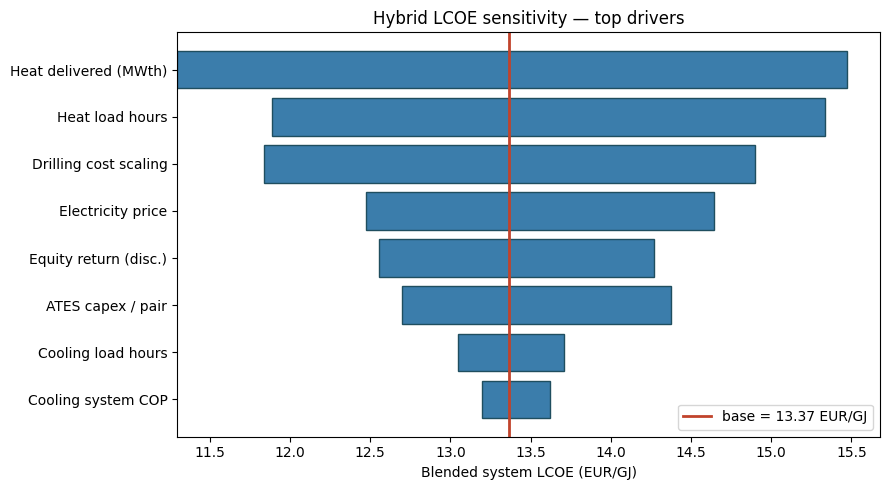

base blended LCOE = 13.37 EUR/GJ


In [7]:
td = tornado_data(cfg)
base = td['base'].iloc[0]
display(td[['driver','low','high','spread']].iloc[::-1].reset_index(drop=True))
fig, ax = plot_tornado(td, base, save_path=FIGURES / 'lcoe_tornado.png')
plt.show()
print(f"base blended LCOE = {base:.2f} EUR/GJ")

**Reading the tornado.** The blended LCOE is **heat-dominated**: resource
deliverability (MWth), heat load hours, and drilling cost open the widest
spreads, followed by electricity price and the 15% equity hurdle. The
cooling-side knobs (ATES capex, cooling load hours, cooling COP) barely move it -
which is why getting the *subsurface* right matters far more than fine-tuning the
cooling plant.

## 6. Refresh the hybrid workbook

Regenerate `data/processed/LCOE_hybrid.xlsx` so the deliverable workbook always
agrees with this notebook and the pipeline. The original `LCOE.xlsx` is never
touched.

In [8]:
build_workbook()
print('wrote data/processed/LCOE_hybrid.xlsx')

wrote data/processed/LCOE_hybrid.xlsx
